**Этот блокнот является упражнением из курса [Компьютерное зрение](https://www.kaggle.com/learn/computer-vision). Вы можете ознакомиться с руководством по [этой ссылке](https://www.kaggle.com/ryanholbrook/convolution-and-relu).**

---


# Введение #

В этом упражнении вы поработаете над формированием интуитивного понимания извлечения признаков. Сначала мы повторим пример из руководства, но на этот раз с ядром, которое вы выберете сами. В этом курсе мы в основном работали с изображениями, но за всеми операциями, которые мы изучаем, стоит математика. Поэтому мы также посмотрим, как эти карты признаков могут быть представлены в виде числовых массивов и какой эффект свёртка с ядром будет на них оказывать.

Запустите ячейку ниже, чтобы начать!

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

tf.config.run_functions_eagerly(True)

# Применение преобразований #

Следующие несколько упражнений проведут вас через процесс извлечения признаков, как в примере из руководства. Запустите следующую ячейку, чтобы загрузить изображение, которое мы будем использовать в следующих упражнениях.

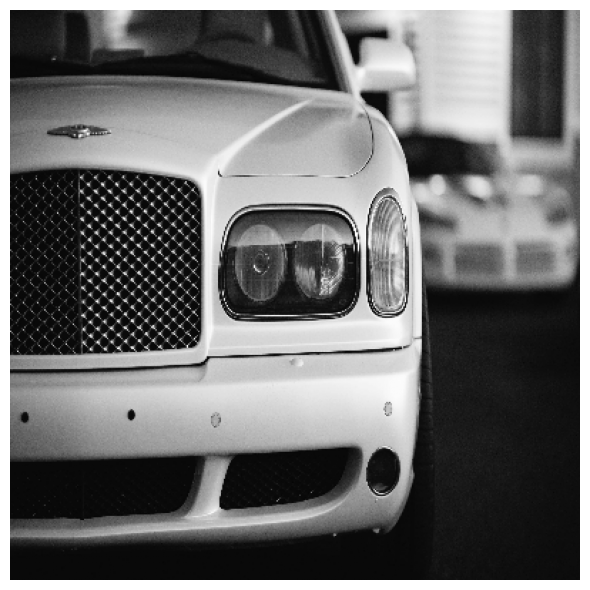

In [2]:
image_path = './img/car_illus.jpg'
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, size=[400, 400])

img = tf.squeeze(image).numpy()
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show();

# 1) Определение ядра #

Используйте следующую ячейку кода, чтобы определить ядро. Вы можете выбрать любое ядро. Стоит помнить, что *сумма* чисел в ядре определяет, насколько ярким будет итоговое изображение. В целом, старайтесь, чтобы сумма чисел была между 0 и 1 (хотя это не обязательно для правильного ответа).

В общем случае ядро может иметь любое количество строк и столбцов. Для этого упражнения давайте используем ядро размером $3 \times 3$, которое часто даёт наилучшие результаты. Определите ядро с помощью `tf.constant`.

In [6]:
# YOUR CODE HERE: Define a kernel with 3 rows and 3 columns.
kernel = tf.constant([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2],
])
# Uncomment to view kernel
# visiontools.show_kernel(kernel)

# Check your answer
# q_1.check()

In [ ]:
# Lines below will give you a hint or solution code
#q_1.hint()
#q_1.solution()

Теперь мы выполним первый шаг извлечения признаков — этап фильтрации. Сначала запустите эту ячейку, чтобы выполнить некоторую подготовительную работу по преобразованию изображения и ядра.

In [7]:
# Reformat for batch compatibility.
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

# 2) Применение свёртки #

Теперь мы применим ядро к изображению с помощью свёртки. *Слой* в Keras, который выполняет эту операцию, — это `tf.keras.layers.Conv2D`. Однако в TensorFlow есть и более низкоуровневая функция `tf.nn.conv2d`, которая напрямую реализует свёртку. В этом упражнении мы будем использовать эту функцию, а не слой Keras, чтобы лучше понять происходящее.

Вам нужно будет указать `input`, `filters`, `strides` и `padding`. Воспользуйтесь помощью по функции, чтобы узнать, как их задать. (Нажмите здесь, чтобы открыть справку по Python, или используйте `Shift+Tab` для отображения всплывающей подсказки.)

In [8]:
# YOUR CODE HERE: Give the TensorFlow convolution function (without arguments)
conv_fn = conv_fn = tf.nn.conv2d

# Check your answer
# q_2.check()

In [ ]:
# Lines below will give you a hint or solution code
#q_2.hint()
#q_2.solution()

Когда вы получите правильный ответ, запустите следующую ячейку, чтобы выполнить свёртку и увидеть результат!

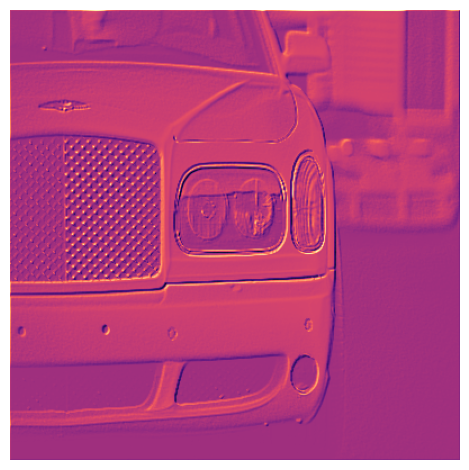

In [9]:
image_filter = conv_fn(
    input=image,
    filters=kernel,
    strides=1,  # or (1, 1)
    padding='SAME',
)

plt.imshow(
    # Reformat for plotting
    tf.squeeze(image_filter)
)
plt.axis('off')
plt.show();

Видите ли вы, как выбранное вами ядро связано с полученной картой признаков?

# 3) Применение ReLU #

Теперь обнаружьте признак с помощью функции ReLU. В Keras вы обычно будете использовать её как функцию активации в слое `Conv2D`. Как называется *внутренняя функция* в TensorFlow, которая делает то же самое?

In [11]:
# YOUR CODE HERE: Give the TensorFlow ReLU function (without arguments)
relu_fn = tf.nn.relu

# Check your answer
# q_3.check()

Когда вы получите решение, запустите эту ячейку, чтобы обнаружить признак с помощью ReLU и увидеть результат!

Изображение ниже — это карта признаков, полученная с помощью выбранного вами ядра. Если хотите, поэкспериментируйте с другими предложенными ядрами выше или попробуйте придумать своё, которое будет извлекать определённый тип признака.


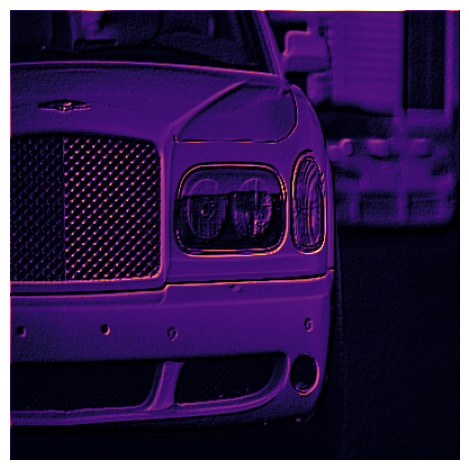

In [12]:
image_detect = relu_fn(image_filter)

plt.imshow(
    # Reformat for plotting
    tf.squeeze(image_detect)
)
plt.axis('off')
plt.show();

В руководстве наше обсуждение ядер и карт признаков было в основном визуальным. Мы видели эффект `Conv2D` и `ReLU`, наблюдая, как они преобразуют некоторые примеры изображений.

Но операции в свёрточной сети (как и во всех нейронных сетях) обычно определяются через математические функции, через вычисления над числами. В следующем упражнении мы уделим время изучению этой точки зрения.

Давайте начнём с определения простого массива, который будет играть роль изображения, и другого массива — в роли ядра. Запустите следующую ячейку, чтобы увидеть эти массивы.

In [13]:
# Sympy - это библиотека python для символьной математики. У нее есть приятный
# симпатичный принтер для матриц, и это все, для чего мы его будем использовать.
import sympy
sympy.init_printing()
from IPython.display import display

image = np.array([
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1],
    [0, 1, 0, 0, 0, 0],
])

kernel = np.array([
    [1, -1],
    [1, -1],
])

display(sympy.Matrix(image))
display(sympy.Matrix(kernel))
# Reformat for Tensorflow
image = tf.cast(image, dtype=tf.float32)
image = tf.reshape(image, [1, *image.shape, 1])
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

⎡0  1  0  0  0  0⎤
⎢                ⎥
⎢0  1  0  0  0  0⎥
⎢                ⎥
⎢0  1  0  0  0  0⎥
⎢                ⎥
⎢0  1  0  0  0  0⎥
⎢                ⎥
⎢0  1  0  1  1  1⎥
⎢                ⎥
⎣0  1  0  0  0  0⎦

⎡1  -1⎤
⎢     ⎥
⎣1  -1⎦

# 4) Наблюдение свёртки на числовой матрице #

Что вы видите? Изображение представляет собой просто длинную вертикальную линию слева и короткую горизонтальную линию справа внизу. А что насчёт ядра? Какой эффект, по вашему мнению, оно окажет на это изображение? Подумайте, а затем запустите следующую ячейку для ответа.

Правильно:

В обучающем руководстве мы говорили о том, что по расположению положительных 
чисел можно понять, какие признаки будет извлекать ядро. В этом ядре есть 
вертикальный столбец из единиц, поэтому можно предположить, что оно будет 
извлекать признаки вертикальных линий.

Теперь давайте попробуем. Запустите следующую ячейку, чтобы применить свёртку и ReLU к изображению и отобразить результат.

In [14]:
image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=1,
    padding='VALID',
)
image_detect = tf.nn.relu(image_filter)

# The first matrix is the image after convolution, and the second is
# the image after ReLU.
display(sympy.Matrix(tf.squeeze(image_filter).numpy()))
display(sympy.Matrix(tf.squeeze(image_detect).numpy()))

⎡-2.0  2.0   0    0  0⎤
⎢                     ⎥
⎢-2.0  2.0   0    0  0⎥
⎢                     ⎥
⎢-2.0  2.0   0    0  0⎥
⎢                     ⎥
⎢-2.0  2.0  -1.0  0  0⎥
⎢                     ⎥
⎣-2.0  2.0  -1.0  0  0⎦

⎡0  2.0  0  0  0⎤
⎢               ⎥
⎢0  2.0  0  0  0⎥
⎢               ⎥
⎢0  2.0  0  0  0⎥
⎢               ⎥
⎢0  2.0  0  0  0⎥
⎢               ⎥
⎣0  2.0  0  0  0⎦

Совпадает ли результат с вашими ожиданиями?

# Заключение #

На этом уроке вы узнали о первых двух операциях, которые использует свёрточный классификатор для извлечения признаков: **фильтрация** изображения с помощью **свёртки** и **обнаружение** признака с помощью **выпрямленного линейного блока (ReLU)**.

# Продолжайте обучение #

Переходите к [**Уроку 3**](https://www.kaggle.com/ryanholbrook/maximum-pooling), чтобы изучить финальную операцию: **сжатие** карты признаков с помощью **максимального пулинга**!

---



*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*